# K-Fold Cross-Validation — Every Point Gets a Turn

A single train/test split gives one number, and that number depends on which rows happened to land
in the test set. Split again with a different shuffle and the score moves. With a small dataset it
can move a lot — enough to reverse which of two models looks better.

**K-fold cross-validation** removes that luck. Instead of holding out one fifth of the data once, it
partitions the data into $K$ folds and runs $K$ separate experiments, each holding out a different
fold. Every point is tested on exactly once and trained on $K-1$ times, and the $K$ scores are
averaged. This notebook draws the fold structure as an image so the mechanics are unmistakable
before we start relying on them.

## Learning objectives

- Explain why a single train/test split gives a noisy estimate of performance
- Partition data into $K$ folds with `KFold` and iterate over the resulting index arrays
- State how many times each point is trained on and tested on across the full procedure
- Read a fold-assignment matrix and verify the partition is disjoint and complete
- Describe the trade-off in choosing $K$

## Background

This notebook assumes a train/test split and the idea of a held-out score, both from
`U1-3_Regression-1_ModelCompare`, and the model-selection problem motivated by
`U1-3_Regression-2_Overfitting` — where the peak of a test curve was located by eye on a single
split.

No model is fit here. The subject is the splitting scheme itself.

**Prerequisites:** `U1-3_Regression-1_ModelCompare` (train/test split),
`U1-3_Regression-2_Overfitting` (why we need a reliable held-out score)

**Dataset:** none — 20 random values, used only for their positions.

**References:** https://scikit-learn.org/stable/modules/cross_validation.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Create the data

Twenty points is deliberately tiny. We never fit a model to them — only their *positions* matter,
because the subject here is which indices land in which fold. A small $n$ keeps the fold picture
legible, and it is also where cross-validation earns its keep: with 20 points, a single 80/20 split
would put just 4 points in the test set, and a score computed on 4 points is close to worthless.

In [2]:
nPts = 20

X = np.random.randn(nPts,1)
X

array([[ 0.02277863],
       [-1.07969252],
       [ 0.96960366],
       [-0.02695102],
       [-0.38328421],
       [ 0.18334388],
       [ 0.23340947],
       [-1.09394904],
       [ 0.39171496],
       [-1.43045069],
       [-0.76591831],
       [-0.42376261],
       [ 1.18509248],
       [ 0.81907862],
       [-1.12514613],
       [-1.19512841],
       [-0.67963297],
       [-1.79164271],
       [-0.92851079],
       [-0.95895096]])

## 2. Visualizing K-fold cross-validation

`KFold` partitions the indices $\{1, \ldots, n\}$ into $K$ disjoint folds
$\mathcal{D}_1, \ldots, \mathcal{D}_K$ of roughly equal size. For each $k$, the model trains on
everything except $\mathcal{D}_k$ and is scored on $\mathcal{D}_k$; the reported performance is the
average across folds:

$$\text{CV score} = \frac{1}{K}\sum_{k=1}^{K} \text{score}\!\left(f^{(-k)},\ \mathcal{D}_k\right)$$

where $f^{(-k)}$ is the model trained with fold $k$ withheld.

Two facts follow from the partition being disjoint and complete, and both are worth stating
explicitly because they are what make the method work:

- **Every point is tested exactly once.** No point contributes to more than one held-out score, so
  the $K$ scores together cover the whole dataset.
- **Every point is trained on exactly $K-1$ times.** Nothing is wasted — with a single split, the
  test fifth is never learned from at all.

`shuffle=True` randomizes the assignment before splitting, which matters whenever the rows arrive in
a meaningful order — sorted by date, or grouped by class. Without it, fold 1 would be the first
20% of the file.

Each row of the image below is one fold: **white = trained on, black = held out**. Read down a
column to see one data point's fate across all five experiments — it should be black exactly once.

16 4 20
16 4 20
16 4 20
16 4 20
16 4 20


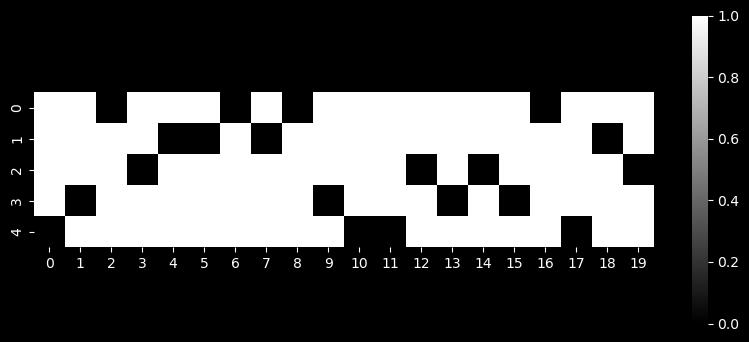

In [3]:
from sklearn.model_selection import KFold

n_splits = 5

kf = KFold(n_splits=n_splits, shuffle=True)

matrix = np.zeros((n_splits,nPts))

for i, (train_index, test_index) in enumerate(kf.split(X)):
    matrix[i,train_index] = 1
    matrix[i,test_index] = 0
    print(len(train_index),len(test_index),len(X))
# end

plt.figure(figsize=(10,4))
sns.heatmap(matrix, cmap='gray');
plt.gca().set_aspect('equal')

The black blocks tile the image without overlapping and without gaps. That is the partition
property drawn: the held-out sets are disjoint, and together they cover every column.

The printed row shows the train/test/total sizes per fold. With $n = 20$ and $K = 5$, each fold
holds out 4 points and trains on 16 — so each model sees 80% of the data, the same as a single
80/20 split, but we get five such estimates instead of one and every point is tested on.

**Choosing $K$** is a trade-off. Larger $K$ means more training data per fold, so less bias in the
estimate, but $K$ fits instead of one and the training sets overlap heavily, which makes the $K$
scores correlated. $K = 5$ and $K = 10$ are the standard compromises. At the extreme,
$K = n$ is *leave-one-out* cross-validation: maximal training data, and $n$ separate fits.

## 3. Review

- **A single train/test split gives a lucky or unlucky number.** Which rows land in the test set
  changes the score, badly so when the dataset is small.
- **K-fold partitions the data into $K$ disjoint folds** and runs $K$ experiments, each holding out
  a different fold, then averages:
  $\frac{1}{K}\sum_k \text{score}(f^{(-k)}, \mathcal{D}_k)$.
- **Every point is tested exactly once and trained on $K-1$ times**, which is visible in the image
  as one black block per column.
- **`shuffle=True` matters** whenever the data arrives in a meaningful order; without it the folds
  are contiguous slices of the file.
- **Larger $K$ trades compute for a less biased estimate**, with $K = 5$ or $10$ the usual choice
  and $K = n$ being leave-one-out.
- Cross-validation is the scoring machinery that `U1-3_Regression-4_GridSearchCV` uses to compare
  hyperparameter settings fairly.